# Working with and visualizing 4 dimensional datasets

Often times, oceanography datasets are 4-dimensional with latitude, longitude, depth, and time dimensions. 

In this workbook, we will walk through a couple types of figures oceanographers commonly use to visualize multi-dimensional datasets. 
For these examples we will use [SalishSeaCast](https://salishsea.eos.ubc.ca/nemo/) model data. This data source provides clean, consistently binned 4D data which will be useful for this example, but think about how visualizations may change when working with data that has non-uniform data bins, gaps, etc. 

In [11]:
# import data packages cell  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import urllib.parse
import time
import requests
import io
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import xarray

## A tiny bit of background behind Salish Sea Cast 

SalishSeaCast is a regional biogeochemical model built on NEMO architechture developed at the University of British Columbia led by Susan Allen. The Salish Sea is a marginal sea between Vancouver Island and the Southern BC mainland. Water enters the semi-enclosed basin of the Salish Sea through the Strait of Juan de Fuca in the south and the Johnstone Strait in the north. The model domain covers a rotated rectangular prisim. The rectangle consists of a 398 x 898 grid space and 40 depth levels. Each grid cell covers a 500m x 500m space. 

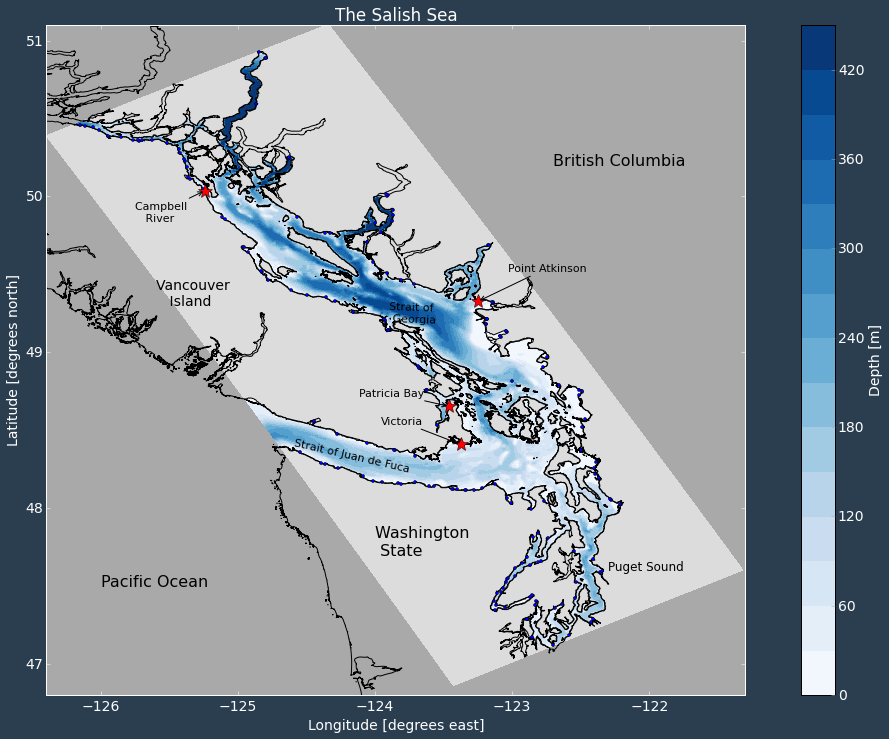!

### Project Resources
The main project documentation site is at [https://salishsea-meopar-docs.readthedocs.io/en/latest/].
The project team maintains a set of Git version control repositories for code, documentation (including the source files for this site), and analyses of model results. The contents of those repositories and their development history is accessible at [https://github.com/SalishSeaCast].

### Accessing the data behind the plots

`SalishSeaCast` data is accessible via ERDDAP in `griddap` format. This allows you to subset very large datafiles into more manageable chunks that won't crash your kernel. In the cell below we will create a function that will build ERDDAP urls for us so we can pull just the data we need to create each plot. 

You will find datasets are segregated by temporal resolution (hourly or monthly) and according to model fields (Physics, Chemistry, Biology, Light Fields). Use the table below to determine which terms you should plug into the ERDDAP url builder function 

| Parameter | Temporal Resolution | dataset_id |
| --- | --- | --- |
| temperature | monthly | ubcSSg3DPhysicsFields1moV21-11 | 
| | hourly | ubcSSg3DPhysicsFields1hV21-11 | 
| salinity | monthly | ubcSSg3DPhysicsFields1moV21-11 |
| | hourly | ubcSSg3DPhysicsFields1hV21-11 |
| sigma_theta | monthly | ubcSSg3DPhysicsFields1moV21-11 |
| | hourly | ubcSSg3DPhysicsFields1hV21-11 |
| total_alkalinity | monthly | ubcSSg3DChemistryFields1moV21-11 | 
| | hourly | ubcSSg3DChemistryFields1hV21-11 | 
| dissolved_inorganic_carbon | monthly | ubcSSg3DChemistryFields1moV21-11 |
| | hourly | ubcSSg3DChemistryFields1hV21-11 |
| dissolved_oxygen | monthly | ubcSSg3DChemistryFields1moV21-11 |
| | hourly | ubcSSg3DChemistryFields1hV21-11 |
| flagellates | monthly | ubcSSg3DBiologyFields1moV21-11 | 
| | hourly | ubcSSg3DBiologyFields1hV21-11 | 
| diatoms | monthly | ubcSSg3DBiologyFields1moV21-11 |
| | hourly | ubcSSg3DBiologyFields1hV21-11 |
| z1_zooplankton | monthly | ubcSSg3DBiologyFields1moV21-11 | 
| | hourly |  ubcSSg3DBiologyFields1hV21-11 |
| z2_zooplankton | monthly | ubcSSg3DBiologyFields1moV21-11 |
| | hourly | ubcSSg3DBiologyFields1hV21-11 |
| silicon | monthly | ubcSSg3DBiologyFields1moV21-11 |
| | hourly | ubcSSg3DBiologyFields1hV21-11 | 
| biogenic_silicon| monthly | ubcSSg3DBiologyFields1moV21-11 | 
| | hourly | ubcSSg3DBiologyFields1hV21-11 | 
| ammonium | monthly | ubcSSg3DBiologyFields1moV21-11 | 
| | hourly | ubcSSg3DBiologyFields1hV21-11 |
| particulate_organic_nitrogen | monthly | ubcSSg3DBiologyFields1moV21-11 |
| | hourly | ubcSSg3DBiologyFields1hV21-11 | 
| dissolved_organic_nitrogen | monthly | ubcSSg3DBiologyFields1moV21-11 |
| | hourly | ubcSSg3DBiologyFields1hV21-11 |
| nitrate | monthly | ubcSSg3DBiologyFields1moV21-11 | 
| | hourly | ubcSSg3DBiologyFields1hV21-11 | 
| PAR | monthly | ubcSSg3DLightFields1moV21-11 | 
| | hourly | ubcSSg3DLightFields1hV21-11 | 
| turbidity | monthly | ubcSSg3DLightFields1moV21-11 | 
| | hourly | ubcSSg3DLightFields1hV21-11 | 

In [12]:
# ERDDAP builder function -- 
# Reusable helpers for building and fetching SalishSeaCast griddap data

SalishSeaERDDAP = 'https://salishsea.eos.ubc.ca/erddap/griddap/'
filetype = '.nc'

# Full model domain (see background section above): 40 depth levels, 898 x 398 horizontal grid
FULL_DEPTH = (0.5000003, 1, 441.4661)
FULL_GRIDY = (0, 1, 897.0)
FULL_GRIDX = (0.0, 1, 397.0)

# NOTE! If you are combining parameters of interest from the same dataset_id (e.g. temperature + salinity)
# you can pass them together as one `variables` list to get one url for all the data you want.
# If you are combining data from two or more different dataset_ids, you need to call
# build_griddap_url separately for each dataset_id (e.g. zooplankton + temperature)

def build_griddap_url(dataset_id, variables, time_range, depth_range=FULL_DEPTH,
                       gridY_range=FULL_GRIDY, gridX_range=FULL_GRIDX):
    """
    variables: list of variable names to request
    time_range, depth_range, gridY_range, gridX_range: each a (start, stride, end) tuple.
      Use 'last' as an end value to mean "most recent available".
    Keep each request's ranges as narrow as the plot actually needs -- the
    full domain across many months and variables is several GB and will not fit in memory.
    """
    def fmt(rng):
        start, stride, end = rng
        return f"[({start}):{stride}:({end})]"

    subset = fmt(time_range) + fmt(depth_range) + fmt(gridY_range) + fmt(gridX_range)
    query = ','.join(f"{v}{subset}" for v in variables)
    return f"{SalishSeaERDDAP}{dataset_id}{filetype}?{query}"


def fetch_griddap(url):
    """Download a griddap URL and return it as an xarray.Dataset."""
    response = requests.get(url, verify=False)
    response.raise_for_status()
    return xarray.open_dataset(io.BytesIO(response.content))

## Converting from rotated x, y grid to lon, lat 

SalishSeaCast projects onto a rotated x, y grid space. To put values in a geographical context, we need to convert from the x,y grid space to lon, lat. We will create a separate function for this. 

In [ ]:
# Get the grid data
grid_url = 'https://salishsea.eos.ubc.ca/erddap/griddap/ubcSSnBathymetryV21-08.nc?bathymetry%5B(0.0):1:(897.0)%5D%5B(0.0):1:(397.0)%5D,latitude%5B(0.0):1:(897.0)%5D%5B(0.0):1:(397.0)%5D,longitude%5B(0.0):1:(897.0)%5D%5B(0.0):1:(397.0)%5D'
grid = fetch_griddap(grid_url)
latitude = grid.latitude.values
longitude = grid.longitude.values
depth = grid.depth.values

/home/.pixi/envs/default/lib/python3.14/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'salishsea.eos.ubc.ca'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


In [3]:
def latlon2salishgrid(lat_input, lon_input, latitude, longitude):
    """
    Convert latitude/longitude point(s) to the nearest SalishSeaCast grid indices.

    lat_input, lon_input: scalar or 1D array of the same length
    latitude, longitude: 2D grids (gridY, gridX) from the bathymetry dataset
        (e.g. from get_salish_grid())

    Returns (x, y): gridX, gridY index of the nearest grid cell (same shape as input)
    """
    latitude = np.asarray(latitude)
    longitude = np.asarray(longitude)
    lat_input = np.atleast_1d(lat_input)
    lon_input = np.atleast_1d(lon_input)

    x = np.empty(lat_input.shape, dtype=int)
    y = np.empty(lat_input.shape, dtype=int)

    for i, (la, lo) in enumerate(zip(lat_input, lon_input)):
        dist = np.hypot(latitude - la, longitude - lo)
        y[i], x[i] = np.unravel_index(np.argmin(dist), dist.shape)

    return (x[0], y[0]) if x.size == 1 else (x, y)

In [ ]:
# Example usage: most recent year of temperature water column data at a single grid cell
monthsPrior = 12
startTime = (pd.Timestamp.now(tz="UTC") - pd.DateOffset(months=monthsPrior)).strftime("%Y-%m-%dT%H:%M:%S.000Z")

example_url = build_griddap_url(
    dataset_id='ubcSSg3DPhysicsFields1moV21-11',
    variables=['temperature'],
    time_range=(startTime, 1, 'last'),
    depth_range=FULL_DEPTH,                  # Full water column
    gridY_range=(450, 1, 450),               # single grid cell
    gridX_range=(200, 1, 200),
)
print(example_url)
data = fetch_griddap(example_url)
data

## Hovmöller Plots: Combining depth and time dimensions



In [7]:
# First, let's select a point within the model domain

lat_input = 49.247847  # Replace with your own points
lon_input = -123.501925

latlon2salishgrid(lat_input, lon_input,latitude,longitude)
print(x,y)

NameError: name 'latitude' is not defined

## Cross-sectional Plots: Combining depth and 1D horizontal space (e.g. latitude, longitude, or distance along transect, etc) 

Plot your variable of interest along the `thalweg` line through the Salish Sea 

## Animated surface plots: combining 2D space and time


## Come up with a new kind of plot of your own! 